In [1]:
# Step 1: Library import kora and KMeans fast/stable rakhar jonno thread setting kora
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from IPython.display import display
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [5]:
import os
GITHUB_REPO_URL = "https://github.com/abir945/AI_ML_LAB.git"

if "YOUR_USERNAME" in GITHUB_REPO_URL:
    print("⚠️ Demo/local mode running. Final submission-er age GITHUB_REPO_URL replace korte hobe.")
    PROJECT_DIR = "."
else:
    repo_name = GITHUB_REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")
    !rm -rf {repo_name}
    !git clone {GITHUB_REPO_URL}
    PROJECT_DIR = repo_name

DATA_DIR = os.path.join(PROJECT_DIR, "K-Means", "dataset")
MODEL_DIR = os.path.join(PROJECT_DIR, "model")
PLOTS_DIR = os.path.join(PROJECT_DIR, "plots")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

STANDARD_DATA_PATH = os.path.join(DATA_DIR, "train.csv")
# Updated filename based on user feedback
CUSTOM_DATA_PATH = os.path.join(DATA_DIR, "custom.csv")

print("Project directory:", PROJECT_DIR)
print("Training dataset path:", STANDARD_DATA_PATH)
print("Custom dataset path:", CUSTOM_DATA_PATH)

Cloning into 'AI_ML_LAB'...
remote: Enumerating objects: 123, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 123 (delta 45), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (123/123), 2.02 MiB | 15.44 MiB/s, done.
Resolving deltas: 100% (45/45), done.
Project directory: AI_ML_LAB
Training dataset path: AI_ML_LAB/K-Means/dataset/train.csv
Custom dataset path: AI_ML_LAB/K-Means/dataset/custom.csv


## Step 1: Data Loading

The training dataset and custom dataset are loaded from the GitHub-cloned repository. No manual upload is needed during runtime after the repo is set correctly.

In [6]:
# Step 3: Training dataset and custom 10 data point CSV load kora
import pandas as pd
from IPython.display import display

train_df = pd.read_csv(STANDARD_DATA_PATH)
custom_df = pd.read_csv(CUSTOM_DATA_PATH)

print("Training data shape:", train_df.shape)
print("Custom data shape:", custom_df.shape)

print("\nTraining data preview:")
display(train_df.head())

print("\nCustom data preview:")
display(custom_df.head(10))

Training data shape: (10443, 7)
Custom data shape: (10, 7)

Training data preview:


,experience,country,education,languages,frameworks,company_size,salary_usd
0,34.0,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9.0,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8.0,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29.0,USA,Masters,"C++, Ruby","Spring, Angular",Nov-50,214386
4,7.0,USA,Bachelors,"C#, Rust","React, Express",10-Jan,107584



Custom data preview:


,experience,country,education,languages,frameworks,company_size,salary_usd
0,1,India,Bachelors,"Python, JavaScript","Django, React",1-10,42000
1,3,Brazil,Some College,"PHP, JavaScript","Laravel, Vue",11-50,58000
2,6,Canada,Bachelors,"Java, Python","Spring, Flask",51-200,92000
3,9,USA,Masters,"Python, Rust","FastAPI, React",201-1000,135000
4,12,Germany,Bachelors,"C#, JavaScript","ASP.NET, Angular",1001-5000,118000
5,16,UK,Masters,"Ruby, Go","Ruby on Rails, Vue",5000+,142000
6,22,Singapore,PhD,"Java, Go","Spring, Express",201-1000,166000
7,28,USA,Masters,"Swift, Rust","Flask, React",5000+,205000
8,33,USA,PhD,"C++, Python","Flask, ASP.NET",5000+,232000
9,38,Japan,High School,"PHP, Ruby","Laravel, Ruby on Rails",51-200,125000


## Step 2: Extra Data Exploration / EDA

The following EDA steps are useful for this dataset and clustering task. They help detect missing values, wrong categories, scale issues, outliers, and overall feature patterns before K-Means.

In [7]:
# EDA 1: Dataset-er column, datatype, shape, and first/last rows check kora
print("Shape:", train_df.shape)
print("\nColumns:", train_df.columns.tolist())
print("\nData types:")
print(train_df.dtypes)

print("\nFirst 5 rows:")
display(train_df.head())

print("\nLast 5 rows:")
display(train_df.tail())

Shape: (10443, 7)

Columns: ['experience', 'country', 'education', 'languages', 'frameworks', 'company_size', 'salary_usd']

Data types:
experience      float64
country          object
education        object
languages        object
frameworks       object
company_size     object
salary_usd        int64
dtype: object

First 5 rows:


,experience,country,education,languages,frameworks,company_size,salary_usd
0,34.0,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9.0,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8.0,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29.0,USA,Masters,"C++, Ruby","Spring, Angular",Nov-50,214386
4,7.0,USA,Bachelors,"C#, Rust","React, Express",10-Jan,107584



Last 5 rows:


,experience,country,education,languages,frameworks,company_size,salary_usd
10438,34.0,USA,Bachelors,"Ruby, Swift","Django, Angular",1001-5000,154431
10439,NaN,Germany,Masters,"Rust, Java","Django, Angular",201-1000,95968
10440,15.0,USA,Bachelors,"Rust, PHP","Laravel, Express",201-1000,111545
10441,6.0,USA,Bachelors,"Swift, Rust","Express, React",5000+,112681
10442,30.0,Singapore,Masters,"PHP, C++","Ruby on Rails, Ruby on Rails",Nov-50,167996


In [8]:
# EDA 2: Missing values and duplicate rows check kora
missing_table = pd.DataFrame({
    "missing_count": train_df.isnull().sum(),
    "missing_percent": (train_df.isnull().mean() * 100).round(2)
})

print("Missing value summary:")
display(missing_table)

print("Duplicate rows:", train_df.duplicated().sum())

Missing value summary:


,missing_count,missing_percent
experience,1,0.01
country,0,0.00
education,0,0.00
languages,0,0.00
frameworks,0,0.00
company_size,0,0.00
salary_usd,0,0.00


Duplicate rows: 0


In [13]:
# EDA 3: Company size-er Excel/date formatting problem fix kora
# Example: 10-Jan means 1-10 and Nov-50 means 11-50.
def clean_company_size(value):
    if pd.isna(value):
        return value
    value = str(value).strip()
    if value == "10-Jan":
        return "1-10"
    if value == "Nov-50":
        return "11-50"
    return value

train_df["company_size"] = train_df["company_size"].apply(clean_company_size)
custom_df["company_size"] = custom_df["company_size"].apply(clean_company_size)

print("Cleaned company_size values:")
print(sorted(train_df["company_size"].dropna().unique()))

Cleaned company_size values:
['1-10', '1001-5000', '11-50', '201-1000', '5000+', '51-200']


In [10]:
# EDA 4: Numerical column summary dekhte describe() use kora
numeric_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Numerical columns:", numeric_cols)
display(train_df[numeric_cols].describe().T)

Numerical columns: ['experience', 'salary_usd']


,count,mean,std,min,25%,50%,75%,max
experience,10442.0,19.878472,11.815038,0.0,10.0,20.0,30.0,40.0
salary_usd,10443.0,131736.778129,46195.765324,12064.0,98291.5,131291.0,164217.5,273362.0


In [11]:
# EDA 5: Categorical column summary, unique count, and top categories check kora
categorical_cols = train_df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", categorical_cols)

cat_summary = []
for col in categorical_cols:
    cat_summary.append({
        "column": col,
        "unique_count": train_df[col].nunique(),
        "most_common_value": train_df[col].mode()[0],
        "most_common_count": train_df[col].value_counts().iloc[0]
    })

display(pd.DataFrame(cat_summary))

for col in categorical_cols:
    print(f"\nTop values for {col}:")
    display(train_df[col].value_counts().head(10))

Categorical columns: ['country', 'education', 'languages', 'frameworks', 'company_size']


,column,unique_count,most_common_value,most_common_count
0,country,10,USA,4102
1,education,5,Bachelors,5242
2,languages,100,"PHP, PHP",139
3,frameworks,100,"Laravel, Vue",133
4,company_size,6,51-200,1773



Top values for country:


,count
country,
USA,4102
UK,1104
Germany,1046
Canada,1027
India,1011
France,585
Australia,527
Japan,498
Singapore,285



Top values for education:


...

,count
languages,
"PHP, PHP",139
"Java, Python",129
"Java, JavaScript",123
"Ruby, Swift",120
"JavaScript, Rust",120
"Swift, Rust",119
"C++, PHP",118
"JavaScript, C++",118
"Swift, Java",117



Top values for frameworks:


,count
frameworks,
"Laravel, Vue",133
"Spring, ASP.NET",128
"Express, Laravel",127
"Laravel, React",124
"Ruby on Rails, Vue",123
"React, React",121
"Vue, Ruby on Rails",120
"Ruby on Rails, Angular",120
"Flask, ASP.NET",118



Top values for company_size:


,count
company_size,
51-200,1773
1001-5000,1756
1-10,1747
201-1000,1746
5000+,1745
11-50,1676


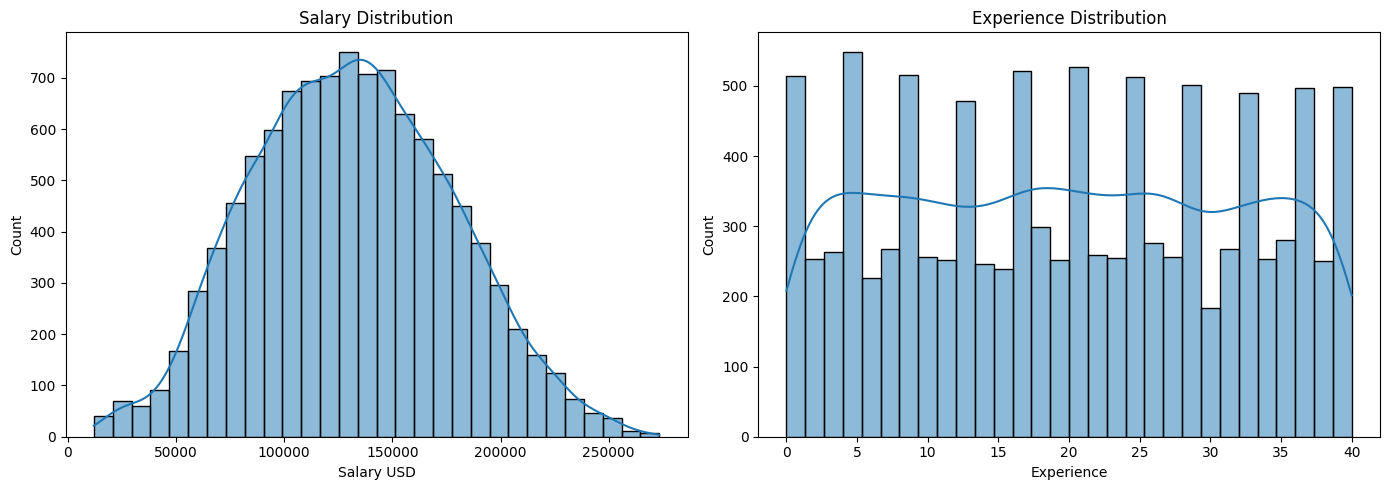

In [14]:
# EDA 6: Salary and experience distribution plot kora
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_df["salary_usd"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Salary Distribution")
axes[0].set_xlabel("Salary USD")

sns.histplot(train_df["experience"].dropna(), bins=30, kde=True, ax=axes[1])
axes[1].set_title("Experience Distribution")
axes[1].set_xlabel("Experience")

plt.tight_layout()
plt.show()

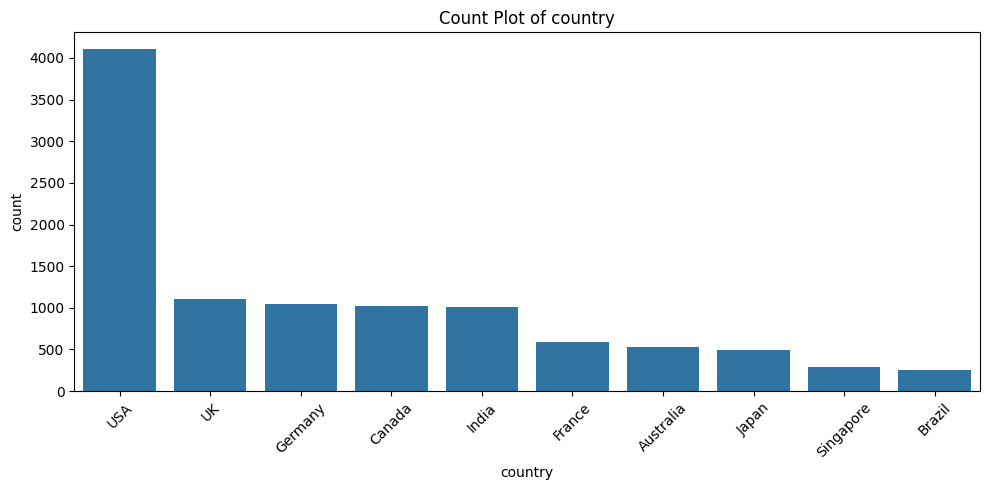

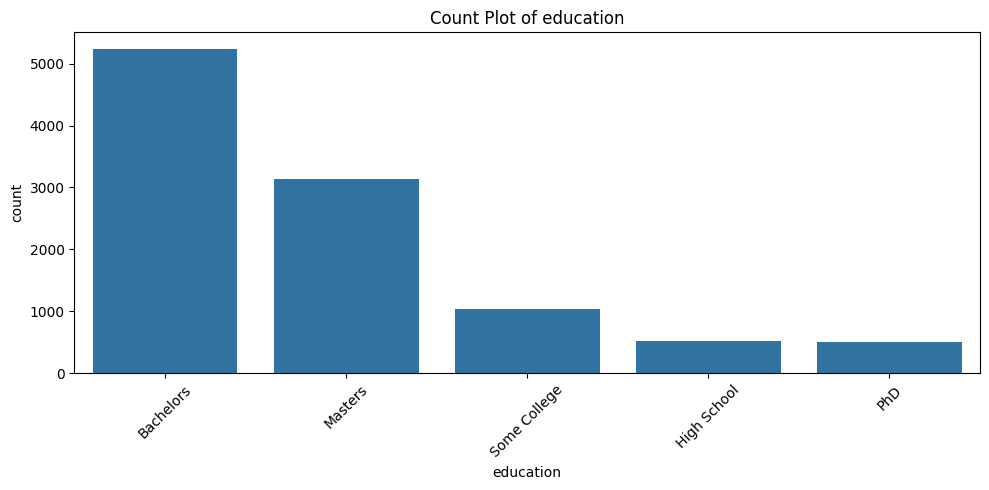

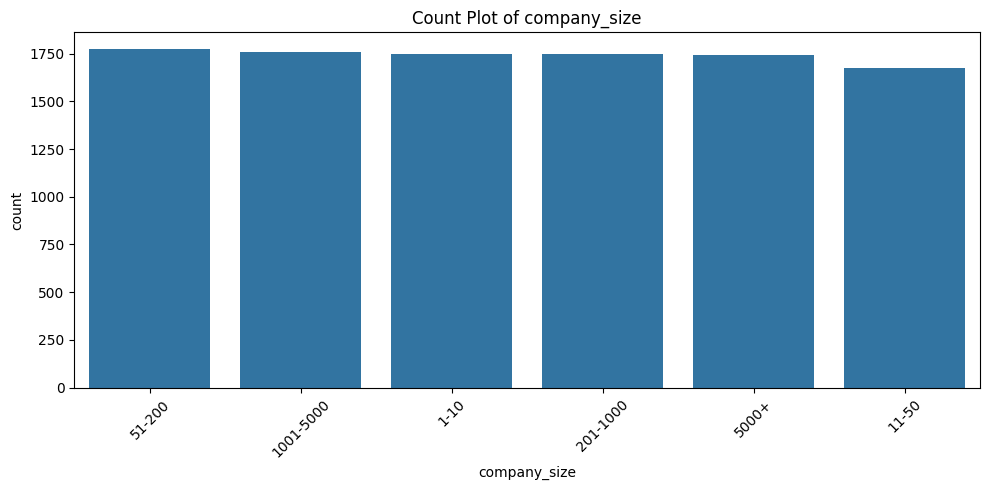

In [19]:
# EDA 7: Country, education, and company size count plot kora
import matplotlib.pyplot as plt
import seaborn as sns

plot_cols = ["country", "education", "company_size"]

for col in plot_cols:
    plt.figure(figsize=(10, 5))
    order = train_df[col].value_counts().index
    sns.countplot(data=train_df, x=col, order=order)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

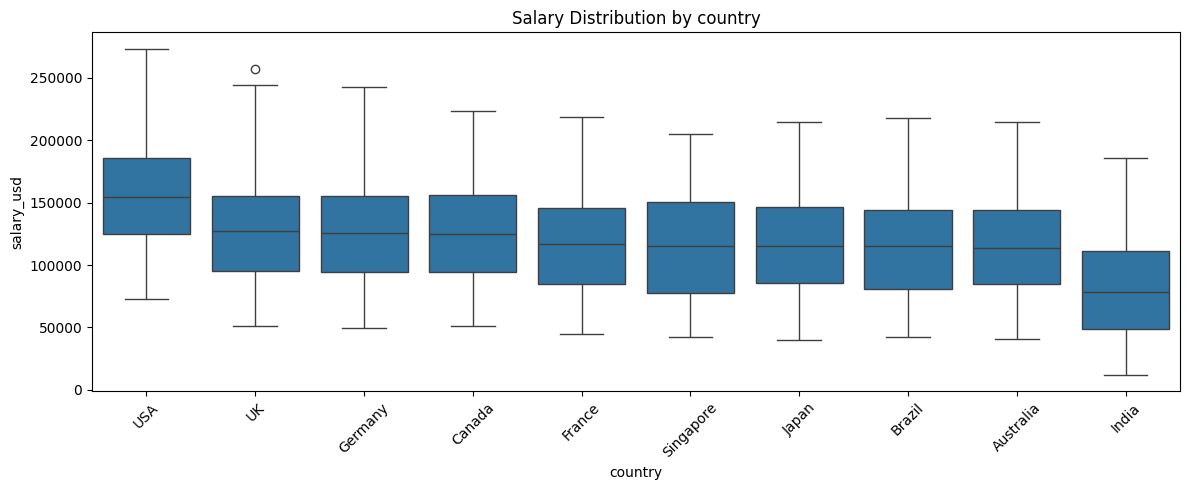

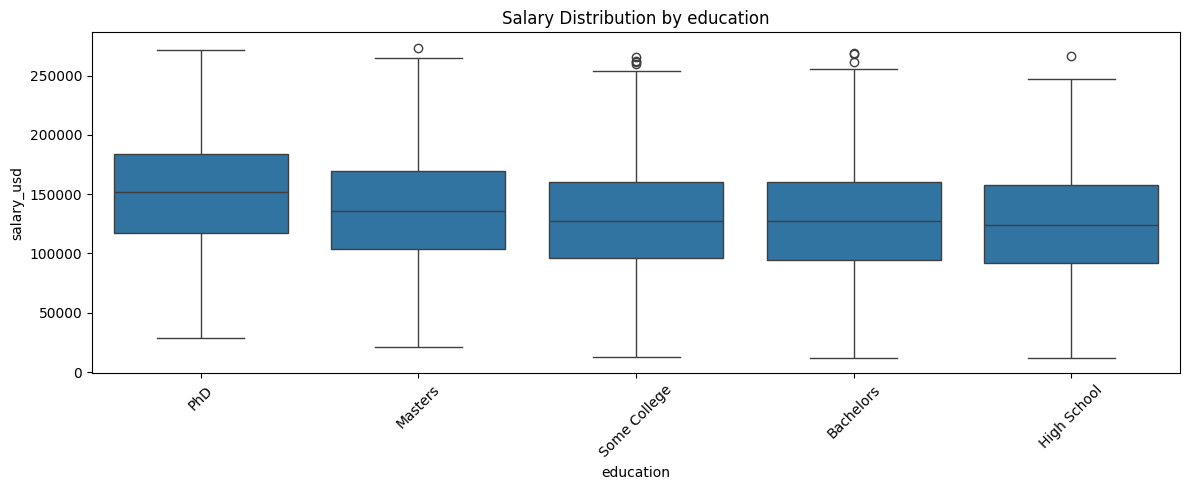

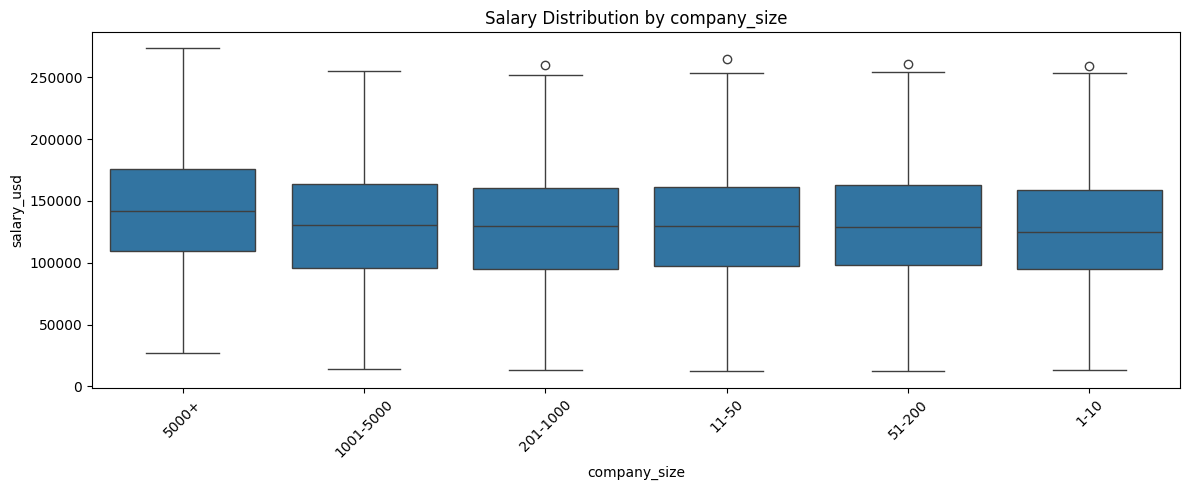

In [20]:
# EDA 8: Salary vs important categorical features boxplot kora
import matplotlib.pyplot as plt
import seaborn as sns

box_cols = ["country", "education", "company_size"]

for col in box_cols:
    plt.figure(figsize=(12, 5))
    order = train_df.groupby(col)["salary_usd"].median().sort_values(ascending=False).index
    sns.boxplot(data=train_df, x=col, y="salary_usd", order=order)
    plt.title(f"Salary Distribution by {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

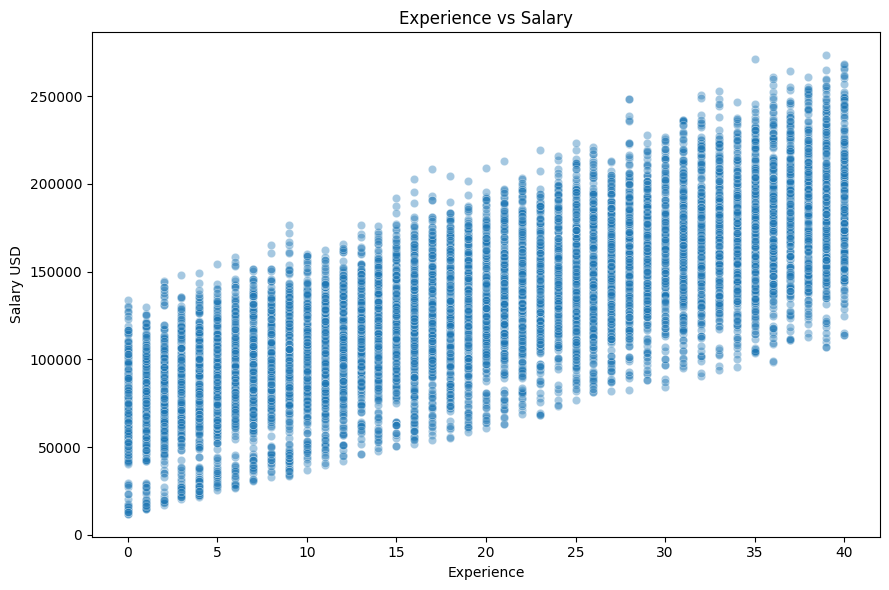

In [17]:
# EDA 9: Experience and salary-er relationship scatter plot diye check kora
plt.figure(figsize=(9, 6))
sns.scatterplot(data=train_df, x="experience", y="salary_usd", alpha=0.4)
plt.title("Experience vs Salary")
plt.xlabel("Experience")
plt.ylabel("Salary USD")
plt.tight_layout()
plt.show()

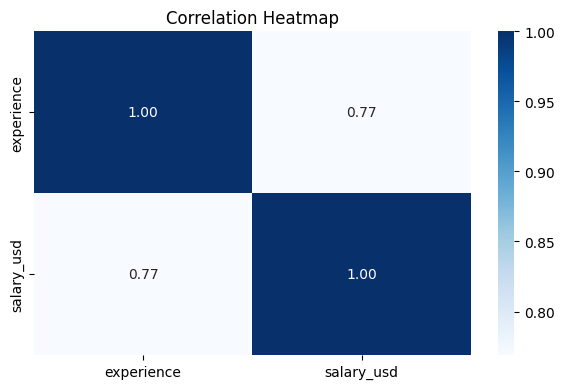

In [18]:
# EDA 10: Numerical feature correlation heatmap dekhano
plt.figure(figsize=(6, 4))
sns.heatmap(train_df[numeric_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [22]:
# EDA 11: Simple IQR method diye numerical outlier count check kora
outlier_report = []

for col in numeric_cols:
    q1 = train_df[col].quantile(0.25)
    q3 = train_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)]
    outlier_report.append({
        "column": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": len(outliers)
    })

display(pd.DataFrame(outlier_report))

,column,lower_bound,upper_bound,outlier_count
0,experience,-20.0,60.0,0
1,salary_usd,-597.5,263106.5,8


## Step 3: Which EDA can be skipped?

For this assignment, **do not skip** missing value check, duplicate check, numerical summary, categorical summary, scaling-related distribution checks, and important plots.  
You **can skip** pairplot, 3D interactive plots, hypothesis testing, advanced outlier treatment, word cloud, and every single category-wise plot because those are not required by the PDF and they make the notebook unnecessarily long.

In [ ]:
# Step 4: Custom data format training data-r sathe exactly match kore kina check kora
required_columns = ["experience", "country", "education", "languages", "frameworks", "company_size", "salary_usd"]

missing_from_train = [col for col in required_columns if col not in train_df.columns]
missing_from_custom = [col for col in required_columns if col not in custom_df.columns]

print("Missing columns in training data:", missing_from_train)
print("Missing columns in custom data:", missing_from_custom)

assert len(missing_from_train) == 0, "Training data column missing."
assert len(missing_from_custom) == 0, "Custom data column missing."

custom_df = custom_df[required_columns].copy()
train_df = train_df[required_columns].copy()

print("✅ Custom data column format matches training data.")
display(custom_df.head(10))

## Step 4: Feature Engineering and Preprocessing

K-Means uses Euclidean distance. So numerical columns must be scaled. Categorical features are encoded using OneHotEncoder. The same fitted preprocessor is later used for custom data prediction.

In [23]:
# Step 5: Languages/frameworks theke model-friendly feature create kora
def first_item(text):
    if pd.isna(text) or str(text).strip() == "":
        return "Unknown"
    return str(text).split(",")[0].strip()

def count_items(text):
    if pd.isna(text) or str(text).strip() == "":
        return 0
    return len([x.strip() for x in str(text).split(",") if x.strip()])

def build_model_features(data):
    data = data.copy()
    data["primary_language"] = data["languages"].apply(first_item)
    data["primary_framework"] = data["frameworks"].apply(first_item)
    data["n_languages" ] = data["languages"].apply(count_items)
    data["n_frameworks"] = data["frameworks"].apply(count_items)

    model_columns = [
        "experience", "salary_usd", "n_languages", "n_frameworks",
        "country", "education", "company_size", "primary_language", "primary_framework"
    ]
    return data[model_columns]

train_features = build_model_features(train_df)
custom_features = build_model_features(custom_df)

print("Training model features preview:")
display(train_features.head())

Training model features preview:


,experience,salary_usd,n_languages,n_frameworks,country,education,company_size,primary_language,primary_framework
0,34.0,172292,2,2,Germany,Masters,201-1000,Rust,Vue
1,9.0,82311,2,2,UK,Masters,201-1000,C#,Ruby on Rails
2,8.0,109637,2,2,USA,Some College,5000+,C++,Vue
3,29.0,214386,2,2,USA,Masters,11-50,C++,Spring
4,7.0,107584,2,2,USA,Bachelors,1-10,C#,React


In [25]:
# Step 6: Numerical scaling and categorical encoding preprocessing pipeline create kora
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = ["experience", "salary_usd", "n_languages", "n_frameworks"]
categorical_features = ["country", "education", "company_size", "primary_language", "primary_framework"]

onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot_encoder)
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

X_processed = preprocessor.fit_transform(train_features)
print("Processed training matrix shape:", X_processed.shape)

Processed training matrix shape: (10443, 45)


## Step 5: Optimal K Selection using Elbow Method

The Elbow Method fits KMeans for multiple K values and stores WCSS/Inertia. The best K is selected from the elbow point.

In [26]:
# Step 7: Elbow Method-er jonno different K value fit kore WCSS/Inertia calculate kora
from sklearn.cluster import KMeans

k_values = list(range(2, 9))
wcss = []

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=3, max_iter=150)
    kmeans_temp.fit(X_processed)
    wcss.append(kmeans_temp.inertia_)
    print(f"K={k}, WCSS/Inertia={kmeans_temp.inertia_:.2f}")

wcss_df = pd.DataFrame({"K": k_values, "WCSS/Inertia": wcss})
display(wcss_df)

K=2, WCSS/Inertia=50033.05
K=3, WCSS/Inertia=47300.82
K=4, WCSS/Inertia=45446.75
K=5, WCSS/Inertia=44172.40
K=6, WCSS/Inertia=43255.28
K=7, WCSS/Inertia=42304.35
K=8, WCSS/Inertia=41512.81


,K,WCSS/Inertia
0,2,50033.047268
1,3,47300.821894
2,4,45446.750602
3,5,44172.395918
4,6,43255.284094
5,7,42304.345407
6,8,41512.814253


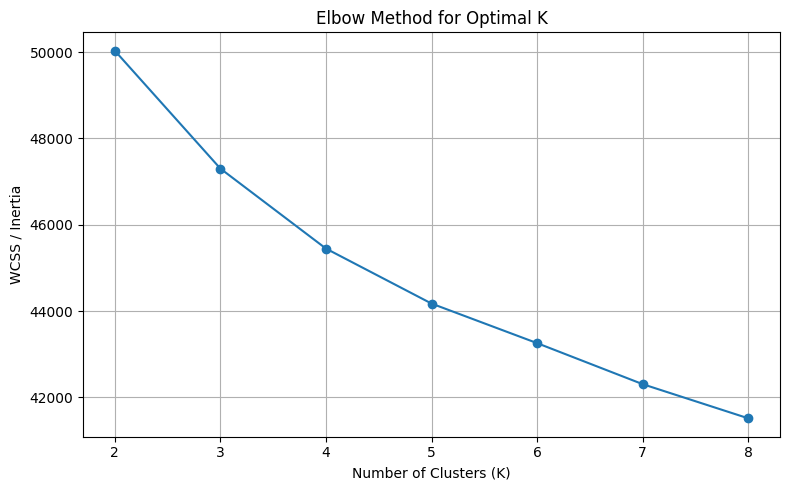

In [27]:
# Step 8: Elbow curve plot kora and plots folder-e save kora
plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "elbow_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

In [32]:
# Step 9: Simple elbow point automatically choose kora
import numpy as np
def choose_k_by_elbow(k_values, wcss):
    x = np.array(k_values, dtype=float)
    y = np.array(wcss, dtype=float)
    points = np.column_stack((x, y))
    start = points[0]
    end = points[-1]
    line = end - start
    distances = []
    for point in points:
        distance = np.abs(np.cross(line, start - point)) / np.linalg.norm(line)
        distances.append(distance)
    best_index = int(np.argmax(distances))
    return int(k_values[best_index])

optimal_k = choose_k_by_elbow(k_values, wcss)
print("✅ Selected optimal K:", optimal_k)

✅ Selected optimal K: 4


/tmp/ipykernel_4149/2067977226.py:12: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distance = np.abs(np.cross(line, start - point)) / np.linalg.norm(line)


## Step 6: Final KMeans Model Fitting and Saving

The final model is trained using the selected optimal K. The trained model pipeline is saved as a `.joblib` file in the `model/` folder.

In [34]:
# Step 10: Optimal K diye final KMeans model train kora
from sklearn.cluster import KMeans
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
final_kmeans.fit(X_processed)

train_clusters = final_kmeans.labels_
train_df_with_cluster = train_df.copy()
train_df_with_cluster["Cluster_ID"] = train_clusters

print("Final KMeans inertia:", final_kmeans.inertia_)
print("Cluster counts:")
print(train_df_with_cluster["Cluster_ID"].value_counts().sort_index())

Final KMeans inertia: 45446.75060154275
Cluster counts:
Cluster_ID
0    2142
1    2827
2    2751
3    2723
Name: count, dtype: int64


In [36]:
# Step 11: Fitted preprocessor and final KMeans model ek sathe joblib file hisebe save kora
import joblib
full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("kmeans", final_kmeans)
])

model_path = os.path.join(MODEL_DIR, "220144_kmeans_pipeline.joblib")
joblib.dump(full_pipeline, model_path)

print("✅ Model saved at:", model_path)

✅ Model saved at: AI_ML_LAB/model/220144_kmeans_pipeline.joblib


## Step 7: Required Cluster Scatter Plot with Centroids

Because the dataset has many encoded features, PCA is used only for 2D visualization. The KMeans model itself is trained on the full processed feature matrix.

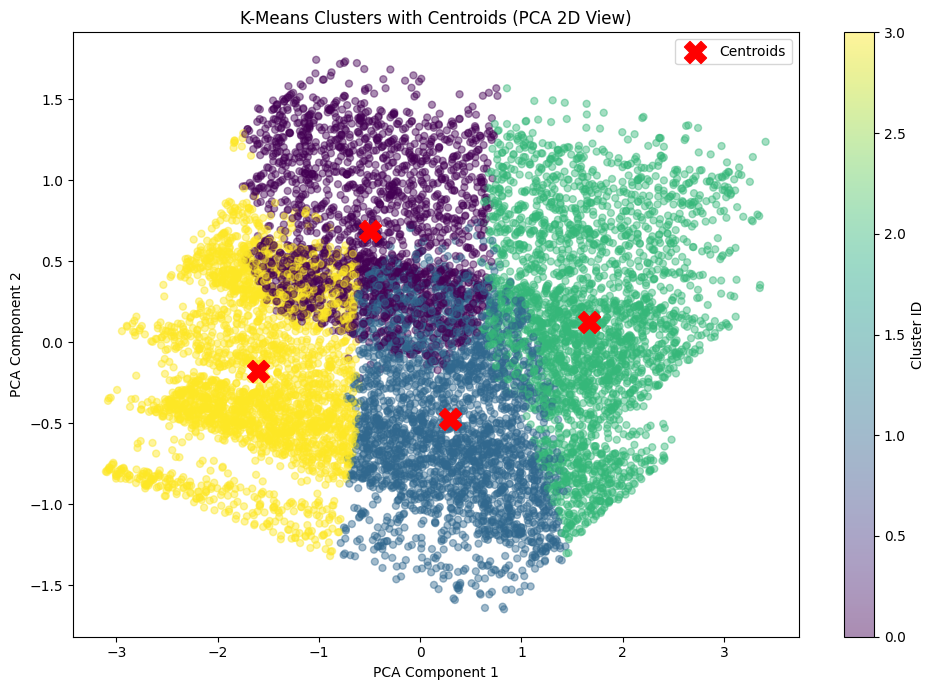

In [37]:
# Step 12: PCA diye 2D cluster scatter plot and centroid plot kora
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)
centroids_pca = pca.transform(final_kmeans.cluster_centers_)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=train_clusters, cmap='viridis', alpha=0.45, s=25)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=250, label='Centroids')
plt.title('K-Means Clusters with Centroids (PCA 2D View)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.colorbar(scatter, label='Cluster ID')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'cluster_scatter_pca.png'), dpi=300, bbox_inches='tight')
plt.show()

## Step 8: Real-World Custom Data Prediction

The custom data is passed through the **same fitted preprocessor/scaler** and then the trained KMeans model assigns cluster IDs.

In [38]:
# Step 13: Custom 10 data point-er cluster prediction kora using same fitted scaler/preprocessor
custom_clusters = full_pipeline.predict(custom_features)

custom_prediction_output = custom_df.copy()
custom_prediction_output["Assigned_Cluster_ID"] = custom_clusters

print("Custom prediction output:")
display(custom_prediction_output)

custom_output_path = os.path.join(PLOTS_DIR, "custom_predictions.csv")
custom_prediction_output.to_csv(custom_output_path, index=False)
print("✅ Custom predictions saved at:", custom_output_path)

Custom prediction output:


,experience,country,education,languages,frameworks,company_size,salary_usd,Assigned_Cluster_ID
0,1,India,Bachelors,"Python, JavaScript","Django, React",1-10,42000,3
1,3,Brazil,Some College,"PHP, JavaScript","Laravel, Vue",11-50,58000,3
2,6,Canada,Bachelors,"Java, Python","Spring, Flask",51-200,92000,3
3,9,USA,Masters,"Python, Rust","FastAPI, React",201-1000,135000,0
4,12,Germany,Bachelors,"C#, JavaScript","ASP.NET, Angular",1001-5000,118000,3
5,16,UK,Masters,"Ruby, Go","Ruby on Rails, Vue",5000+,142000,1
6,22,Singapore,PhD,"Java, Go","Spring, Express",201-1000,166000,1
7,28,USA,Masters,"Swift, Rust","Flask, React",5000+,205000,2
8,33,USA,PhD,"C++, Python","Flask, ASP.NET",5000+,232000,2
9,38,Japan,High School,"PHP, Ruby","Laravel, Ruby on Rails",51-200,125000,1


✅ Custom predictions saved at: AI_ML_LAB/plots/custom_predictions.csv


## Step 9: Cluster Interpretation

The following table summarizes each cluster. Use this summary to write the final 2-3 sentence cluster profile in your README.

In [39]:
# Step 14: Cluster-wise average and most common category diye interpretation table create kora
profile_df = train_features.copy()
profile_df['Cluster_ID'] = train_clusters

numeric_features = ['experience', 'salary_usd', 'n_languages', 'n_frameworks']
categorical_features = ['country', 'education', 'company_size', 'primary_language', 'primary_framework']

numeric_profile = profile_df.groupby('Cluster_ID')[numeric_features].mean().round(2)
count_profile = profile_df.groupby('Cluster_ID').size().rename('count')

mode_profile = profile_df.groupby('Cluster_ID')[categorical_features].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')

cluster_profile = pd.concat([count_profile, numeric_profile, mode_profile], axis=1)
display(cluster_profile)

,count,experience,salary_usd,n_languages,n_frameworks,country,education,company_size,primary_language,primary_framework
Cluster_ID,,,,,,,,,,
0,2142,11.10,129146.64,2.0,2.0,USA,Bachelors,1-10,Java,Spring
1,2827,25.84,130988.65,2.0,2.0,UK,Bachelors,201-1000,Ruby,Flask
2,2751,32.52,189318.76,2.0,2.0,USA,Bachelors,5000+,Swift,Flask
3,2723,7.83,76376.89,2.0,2.0,India,Bachelors,1001-5000,Swift,Ruby on Rails


### Final Cluster Interpretation Text

Cluster 3 generally represents junior or lower-salary software profiles because it has lower average experience and lower average salary. Cluster 2 generally represents senior and high-salary profiles, often connected with higher experience and larger salary values. Cluster 0 and Cluster 1 are middle groups where experience, salary, country, education, company size, language, and framework patterns create separate developer-profile segments.